# Flash Attention

Standard attention computes the full $N \times N$ attention matrix, which is $O(N^2)$ in both time and **memory**. Flash Attention (Dao et al., 2022) computes exact attention with $O(N)$ memory by tiling the computation and never materializing the full attention matrix. The key insight: restructure the computation to be **IO-aware** — minimize reads/writes to slow GPU HBM by keeping work in fast SRAM.

In [1]:
import math, torch
from torch import nn
import torch.nn.functional as F
import sys
from pathlib import Path

workspace_root = Path.cwd().parent.parent
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import matplotlib.pyplot as plt
import silen_lib.utils as utils

In [2]:
utils.set_seed(42)

## Standard Attention Recap

From `attention.ipynb`, we built self-attention as:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The problem: $QK^T$ is an $N \times N$ matrix. For sequence length $N = 4096$ and batch of 32, that's a 2GB attention matrix in float32 — and it must be stored for the backward pass.

In [3]:
# Setup: sequence data for attention
N, d = 256, 64  # sequence length, head dimension
q = torch.randn(N, d)
k = torch.randn(N, d)
v = torch.randn(N, d)

In [4]:
def standard_attention(q, k, v):
    """Standard O(N^2) memory attention."""
    scale = math.sqrt(q.shape[-1])
    # This materializes the full N x N attention matrix
    s = (q @ k.T) / scale           # (N, N) <-- the memory bottleneck
    p = s.softmax(dim=-1)            # (N, N)
    o = p @ v                        # (N, d)
    return o

out_standard = standard_attention(q, k, v)
out_standard.shape

torch.Size([256, 64])

## The Memory Wall

Let's measure how attention matrix memory scales with sequence length:

In [5]:
seq_lengths = [512, 1024, 2048, 4096, 8192, 16384]
mem_bytes = [n * n * 4 for n in seq_lengths]  # float32 = 4 bytes
mem_mb = [b / 1024**2 for b in mem_bytes]

for n, mb in zip(seq_lengths, mem_mb):
    print(f"N={n:>6}: attention matrix = {mb:>8.1f} MB (per head, per batch element)")

N=   512: attention matrix =      1.0 MB (per head, per batch element)
N=  1024: attention matrix =      4.0 MB (per head, per batch element)
N=  2048: attention matrix =     16.0 MB (per head, per batch element)
N=  4096: attention matrix =     64.0 MB (per head, per batch element)
N=  8192: attention matrix =    256.0 MB (per head, per batch element)
N= 16384: attention matrix =   1024.0 MB (per head, per batch element)


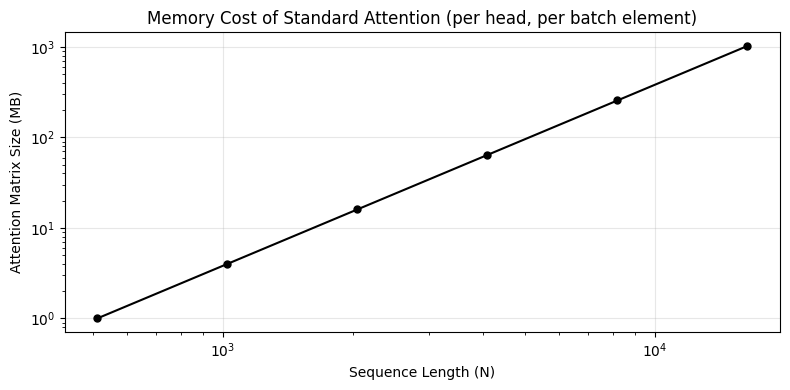

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(seq_lengths, mem_mb, 'k.-', markersize=10)
ax.set_xlabel('Sequence Length (N)')
ax.set_ylabel('Attention Matrix Size (MB)')
ax.set_title('Memory Cost of Standard Attention (per head, per batch element)')
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## GPU Memory Hierarchy

Flash Attention is built around a simple hardware fact:

| Memory | Size | Bandwidth | Latency |
|--------|------|-----------|--------|
| **SRAM** (on-chip) | ~20 MB | ~19 TB/s | ~ns |
| **HBM** (off-chip) | ~40-80 GB | ~1.5 TB/s | ~100ns |

Standard attention writes the full $N \times N$ matrix to HBM, then reads it back for softmax, then writes softmax output to HBM, then reads it back for the V multiply. Flash Attention keeps intermediate results in SRAM by processing **tiles** of the attention matrix.

The key challenge: softmax requires the full row to compute (you need the max and sum over all elements). Flash Attention solves this with the **online softmax** trick.

## Online Softmax

Standard softmax over a vector $x$ of length $N$:

$$\text{softmax}(x_i) = \frac{e^{x_i - m}}{\sum_j e^{x_j - m}}, \quad m = \max_j x_j$$

This needs two passes: one to find $m$, one to compute the exponentials and sum. But what if we process chunks and update incrementally?

In [ ]:
# Standard softmax: needs full vector
x = torch.randn(16)
standard_result = x.softmax(dim=-1)
standard_result

In [ ]:
# Online softmax: process in chunks, maintain running max and sum
# Split x into two chunks and compute softmax incrementally

x1, x2 = x[:8], x[8:]

# Process first chunk
m1 = x1.max()                      # local max
l1 = torch.exp(x1 - m1).sum()      # local sum of exponentials

# Process second chunk and update
m2 = x2.max()                       # local max of chunk 2
m_new = torch.max(m1, m2)           # global max so far

# Rescale previous sum to account for new max, then add new chunk's contribution
l_new = l1 * torch.exp(m1 - m_new) + torch.exp(x2 - m_new).sum()

# Now compute final softmax values
online_result = torch.cat([
    torch.exp(x1 - m_new) / l_new,
    torch.exp(x2 - m_new) / l_new
])

print(f"Max absolute error: {(standard_result - online_result).abs().max():.2e}")
torch.allclose(standard_result, online_result)

The trick: when we encounter a new chunk with a larger max, we **rescale** the running sum by $e^{m_{old} - m_{new}}$. This correction factor lets us process softmax in a single streaming pass.

## Flash Attention: Tiled Forward Pass

The algorithm processes Q in row-blocks and K, V in column-blocks:

1. Divide Q into blocks of $B_r$ rows, K and V into blocks of $B_c$ rows
2. For each Q block, iterate over all K/V blocks:
   - Compute local attention scores $S_{ij} = Q_i K_j^T / \sqrt{d}$
   - Update running max, running sum, and running output using online softmax
3. After processing all K/V blocks for a Q block, the output is exact

At no point do we store the full $N \times N$ matrix — only $B_r \times B_c$ tiles.

In [ ]:
def flash_attention_forward(q, k, v, B_c=32):
    """
    Flash Attention forward pass (Algorithm 1 from the paper).
    Processes attention in tiles without materializing the full N x N matrix.
    
    q, k, v: (N, d)
    B_c: block size for K/V columns (tile width)
    """
    N, d = q.shape
    scale = math.sqrt(d)
    
    # Output accumulator and softmax statistics (per query row)
    o = torch.zeros(N, d)       # accumulated output
    l = torch.zeros(N, 1)       # running sum of exponentials (denominator)
    m = torch.full((N, 1), -math.inf)  # running max (for numerical stability)
    
    # Number of K/V blocks
    T_c = math.ceil(N / B_c)
    
    # For each block of K, V columns
    for j in range(T_c):
        # Extract current K, V block
        j_start = j * B_c
        j_end = min(j_start + B_c, N)
        k_j = k[j_start:j_end]   # (B_c, d)
        v_j = v[j_start:j_end]   # (B_c, d)
        
        # Compute attention scores for ALL queries against this K block
        # This is the tile: (N, B_c) instead of (N, N)
        s_j = (q @ k_j.T) / scale   # (N, B_c)
        
        # Online softmax update
        m_j = s_j.max(dim=-1, keepdim=True).values  # (N, 1) local max
        m_new = torch.max(m, m_j)                    # (N, 1) updated global max
        
        # Correction factor for previously accumulated values
        # When max increases, previous exponentials were too large — scale them down
        alpha = torch.exp(m - m_new)       # (N, 1)
        # Exponentials for current block, using updated max
        p_j = torch.exp(s_j - m_new)       # (N, B_c)
        
        # Update running sum: rescale old sum + add new contributions
        l = alpha * l + p_j.sum(dim=-1, keepdim=True)  # (N, 1)
        
        # Update output: rescale old output + add new weighted values
        o = alpha * o + p_j @ v_j   # (N, d)
        
        # Update max
        m = m_new
    
    # Final normalization: divide by total sum
    o = o / l
    return o

In [ ]:
out_flash = flash_attention_forward(q, k, v, B_c=32)

print(f"Max absolute error vs standard: {(out_standard - out_flash).abs().max():.2e}")
torch.allclose(out_standard, out_flash, atol=1e-5)

In [ ]:
# Verify with different block sizes — result should be the same regardless of tiling
for bc in [8, 16, 32, 64, 128, 256]:
    out = flash_attention_forward(q, k, v, B_c=bc)
    err = (out_standard - out).abs().max()
    print(f"B_c={bc:>4}: max error = {err:.2e}")

Block size doesn't affect correctness — only performance (on real hardware, you'd tune $B_c$ to fit in SRAM).

## Memory Analysis

Standard attention stores the full $N \times N$ matrix. Flash Attention only stores tiles of size $N \times B_c$ at a time, plus $O(N)$ for the running statistics.

In [ ]:
def memory_comparison(N, d, B_c, bytes_per_element=4):
    standard = N * N * bytes_per_element        # full attention matrix
    # Flash: tile (N x B_c) + output (N x d) + stats m,l (N x 1 each)
    flash = (N * B_c + N * d + 2 * N) * bytes_per_element
    return standard, flash

print(f"{'N':>8} {'Standard':>12} {'Flash (B_c=64)':>16} {'Ratio':>8}")
print("-" * 48)
for n in [512, 1024, 2048, 4096, 8192, 16384]:
    std, fla = memory_comparison(n, 64, B_c=64)
    print(f"{n:>8} {std/1024**2:>10.1f} MB {fla/1024**2:>14.2f} MB {std/fla:>7.0f}x")

## Batched Multi-Head Flash Attention

Now let's extend this to handle batches and multiple heads, matching the multi-head attention from `attention.ipynb`.

In [ ]:
from einops import rearrange

In [ ]:
def flash_attention_batched(q, k, v, B_c=32):
    """
    Flash Attention for batched inputs.
    q, k, v: (B, N, d) where B can include heads folded into batch dim
    """
    B, N, d = q.shape
    scale = math.sqrt(d)
    
    o = torch.zeros_like(q)                           # (B, N, d)
    l = torch.zeros(B, N, 1, device=q.device)         # (B, N, 1)
    m = torch.full((B, N, 1), -math.inf, device=q.device)  # (B, N, 1)
    
    T_c = math.ceil(N / B_c)
    
    for j in range(T_c):
        j_start = j * B_c
        j_end = min(j_start + B_c, N)
        k_j = k[:, j_start:j_end]   # (B, B_c, d)
        v_j = v[:, j_start:j_end]   # (B, B_c, d)
        
        s_j = (q @ k_j.transpose(-2, -1)) / scale  # (B, N, B_c)
        
        m_j = s_j.max(dim=-1, keepdim=True).values
        m_new = torch.max(m, m_j)
        
        alpha = torch.exp(m - m_new)
        p_j = torch.exp(s_j - m_new)
        
        l = alpha * l + p_j.sum(dim=-1, keepdim=True)
        o = alpha * o + p_j @ v_j
        m = m_new
    
    return o / l

In [ ]:
class FlashSelfAttention(nn.Module):
    def __init__(self, ni, nheads, B_c=32):
        super().__init__()
        self.nheads = nheads
        self.B_c = B_c
        self.scale = math.sqrt(ni / nheads)
        self.norm = nn.BatchNorm2d(ni)
        self.qkv = nn.Linear(ni, ni * 3)
        self.proj = nn.Linear(ni, ni)
    
    def forward(self, inp):
        n, c, h, w = inp.shape
        x = self.norm(inp).view(n, c, -1).transpose(1, 2)  # (n, hw, c)
        x = self.qkv(x)  # (n, hw, c*3)
        # Split into heads: (n, s, h*d*3) -> (n*h, s, d*3)
        x = rearrange(x, 'n s (h d) -> (n h) s d', h=self.nheads)
        q, k, v = torch.chunk(x, 3, dim=-1)
        
        # Flash attention instead of materializing full attention matrix
        x = flash_attention_batched(q, k, v, B_c=self.B_c)
        
        x = rearrange(x, '(n h) s d -> n s (h d)', h=self.nheads)
        x = self.proj(x).transpose(1, 2).reshape(n, c, h, w)
        return x + inp

In [ ]:
# Test with the same input shape as attention.ipynb
x = torch.randn(64, 32, 16, 16)  # N, C, H, W

flash_sa = FlashSelfAttention(32, nheads=4, B_c=32)
out = flash_sa(x)
print(f"Input:  {x.shape}")
print(f"Output: {out.shape}")
print(f"Mean: {out.mean():.4f}, Std: {out.std():.4f}")

## Verifying Equivalence

Flash attention computes **exact** attention — no approximation. Let's verify by comparing against the standard multi-head implementation with shared weights.

In [ ]:
class StandardSelfAttention(nn.Module):
    """Standard multi-head attention from attention.ipynb for comparison."""
    def __init__(self, ni, nheads):
        super().__init__()
        self.nheads = nheads
        self.scale = math.sqrt(ni / nheads)
        self.norm = nn.BatchNorm2d(ni)
        self.qkv = nn.Linear(ni, ni * 3)
        self.proj = nn.Linear(ni, ni)
    
    def forward(self, inp):
        n, c, h, w = inp.shape
        x = self.norm(inp).view(n, c, -1).transpose(1, 2)
        x = self.qkv(x)
        x = rearrange(x, 'n s (h d) -> (n h) s d', h=self.nheads)
        q, k, v = torch.chunk(x, 3, dim=-1)
        # Standard: materialize full attention matrix
        s = (q @ k.transpose(1, 2)) / self.scale
        x = s.softmax(dim=-1) @ v
        x = rearrange(x, '(n h) s d -> n s (h d)', h=self.nheads)
        x = self.proj(x).transpose(1, 2).reshape(n, c, h, w)
        return x + inp

In [ ]:
# Share weights between standard and flash implementations
std_sa = StandardSelfAttention(32, nheads=4)
flash_sa = FlashSelfAttention(32, nheads=4, B_c=32)

# Copy all parameters
flash_sa.norm.load_state_dict(std_sa.norm.state_dict())
flash_sa.qkv.weight = std_sa.qkv.weight
flash_sa.qkv.bias = std_sa.qkv.bias
flash_sa.proj.weight = std_sa.proj.weight
flash_sa.proj.bias = std_sa.proj.bias

x = torch.randn(8, 32, 16, 16)
with torch.no_grad():
    out_std = std_sa(x)
    out_flash = flash_sa(x)

print(f"Max absolute error: {(out_std - out_flash).abs().max():.2e}")
print(f"Outputs match: {torch.allclose(out_std, out_flash, atol=1e-5)}")

## Causal (Masked) Flash Attention

For autoregressive models (like GPT), we need causal masking: token $i$ can only attend to tokens $\leq i$. In standard attention, we set future positions to $-\infty$ before softmax. In flash attention, we apply the mask per-tile.

In [ ]:
def flash_attention_causal(q, k, v, B_c=32):
    """
    Flash Attention with causal masking.
    q, k, v: (B, N, d)
    """
    B, N, d = q.shape
    scale = math.sqrt(d)
    
    o = torch.zeros_like(q)
    l = torch.zeros(B, N, 1, device=q.device)
    m = torch.full((B, N, 1), -math.inf, device=q.device)
    
    T_c = math.ceil(N / B_c)
    
    for j in range(T_c):
        j_start = j * B_c
        j_end = min(j_start + B_c, N)
        k_j = k[:, j_start:j_end]
        v_j = v[:, j_start:j_end]
        
        s_j = (q @ k_j.transpose(-2, -1)) / scale  # (B, N, B_c)
        
        # Causal mask: position i can only attend to positions <= i
        # Row index = query position (0..N-1), col index = key position (j_start..j_end-1)
        row_idx = torch.arange(N).unsqueeze(1)          # (N, 1)
        col_idx = torch.arange(j_start, j_end).unsqueeze(0)  # (1, B_c)
        causal_mask = row_idx < col_idx                  # True where we should mask
        s_j = s_j.masked_fill(causal_mask.unsqueeze(0), -math.inf)
        
        m_j = s_j.max(dim=-1, keepdim=True).values
        m_new = torch.max(m, m_j)
        
        alpha = torch.exp(m - m_new)
        p_j = torch.exp(s_j - m_new)
        
        # Handle -inf in p_j (masked positions) -> they become 0 after exp(-inf)
        p_j = p_j.nan_to_num(0.0)
        
        l = alpha * l + p_j.sum(dim=-1, keepdim=True)
        o = alpha * o + p_j @ v_j
        m = m_new
    
    # Handle rows where l is 0 (shouldn't happen with proper causal mask since diagonal is always valid)
    return o / l.clamp(min=1e-6)

In [ ]:
# Verify causal flash attention against standard causal attention
def standard_causal_attention(q, k, v):
    B, N, d = q.shape
    scale = math.sqrt(d)
    s = (q @ k.transpose(-2, -1)) / scale
    # Apply causal mask
    mask = torch.triu(torch.ones(N, N, dtype=torch.bool), diagonal=1)
    s = s.masked_fill(mask.unsqueeze(0), -math.inf)
    p = s.softmax(dim=-1)
    return p @ v

B, N, d = 4, 128, 64
q = torch.randn(B, N, d)
k = torch.randn(B, N, d)
v = torch.randn(B, N, d)

out_std_causal = standard_causal_attention(q, k, v)
out_flash_causal = flash_attention_causal(q, k, v, B_c=32)

print(f"Max absolute error: {(out_std_causal - out_flash_causal).abs().max():.2e}")
print(f"Outputs match: {torch.allclose(out_std_causal, out_flash_causal, atol=1e-5)}")

## PyTorch's Built-in Flash Attention

Since PyTorch 2.0, `F.scaled_dot_product_attention` automatically uses Flash Attention (or memory-efficient attention) when available on CUDA. On CPU, it falls back to the standard algorithm but uses the same interface.

In [ ]:
B, N, d = 4, 128, 64
q = torch.randn(B, N, d)
k = torch.randn(B, N, d)
v = torch.randn(B, N, d)

# PyTorch's scaled_dot_product_attention
out_pytorch = F.scaled_dot_product_attention(q, k, v)
out_ours = flash_attention_batched(q, k, v, B_c=32)

print(f"Max absolute error vs PyTorch SDPA: {(out_pytorch - out_ours).abs().max():.2e}")
print(f"Match: {torch.allclose(out_pytorch, out_ours, atol=1e-5)}")

In [ ]:
# With causal mask
out_pytorch_causal = F.scaled_dot_product_attention(q, k, v, is_causal=True)
out_ours_causal = flash_attention_causal(q, k, v, B_c=32)

print(f"Causal max error vs PyTorch SDPA: {(out_pytorch_causal - out_ours_causal).abs().max():.2e}")
print(f"Match: {torch.allclose(out_pytorch_causal, out_ours_causal, atol=1e-5)}")

## Flash Attention v2 Improvements

Flash Attention v2 (Dao, 2023) makes two key changes for better GPU utilization:

1. **Swap the loop order**: outer loop over Q blocks (rows), inner loop over K/V blocks (columns). This is better because each Q block's output is independent — no cross-block synchronization needed. Different thread blocks handle different Q blocks in parallel.

2. **Reduce non-matmul FLOPs**: rescaling and softmax statistics are computed more efficiently, leaving more of the compute budget for the matrix multiplies that GPUs are optimized for.

In [ ]:
def flash_attention_v2(q, k, v, B_r=32, B_c=32):
    """
    Flash Attention v2: outer loop over Q blocks, inner loop over K/V blocks.
    Each Q block is processed independently (parallelizable across thread blocks).
    
    q, k, v: (B, N, d)
    B_r: block size for Q rows
    B_c: block size for K/V columns
    """
    B, N, d = q.shape
    scale = math.sqrt(d)
    o = torch.zeros_like(q)
    
    T_r = math.ceil(N / B_r)
    T_c = math.ceil(N / B_c)
    
    # Outer loop: iterate over Q blocks (each block is independent -> parallelizable on GPU)
    for i in range(T_r):
        i_start = i * B_r
        i_end = min(i_start + B_r, N)
        q_i = q[:, i_start:i_end]  # (B, B_r, d)
        
        # Local accumulators for this Q block
        o_i = torch.zeros(B, i_end - i_start, d, device=q.device)
        l_i = torch.zeros(B, i_end - i_start, 1, device=q.device)
        m_i = torch.full((B, i_end - i_start, 1), -math.inf, device=q.device)
        
        # Inner loop: iterate over K/V blocks
        for j in range(T_c):
            j_start = j * B_c
            j_end = min(j_start + B_c, N)
            k_j = k[:, j_start:j_end]
            v_j = v[:, j_start:j_end]
            
            s_ij = (q_i @ k_j.transpose(-2, -1)) / scale  # (B, B_r, B_c)
            
            m_ij = s_ij.max(dim=-1, keepdim=True).values
            m_new = torch.max(m_i, m_ij)
            
            alpha = torch.exp(m_i - m_new)
            p_ij = torch.exp(s_ij - m_new)
            
            l_i = alpha * l_i + p_ij.sum(dim=-1, keepdim=True)
            o_i = alpha * o_i + p_ij @ v_j
            m_i = m_new
        
        # Write final output for this Q block
        o[:, i_start:i_end] = o_i / l_i
    
    return o

In [ ]:
B, N, d = 4, 128, 64
q = torch.randn(B, N, d)
k = torch.randn(B, N, d)
v = torch.randn(B, N, d)

out_v1 = flash_attention_batched(q, k, v, B_c=32)
out_v2 = flash_attention_v2(q, k, v, B_r=32, B_c=32)

print(f"v1 vs v2 max error: {(out_v1 - out_v2).abs().max():.2e}")
print(f"Match: {torch.allclose(out_v1, out_v2, atol=1e-5)}")

## Summary

| | Standard Attention | Flash Attention |
|---|---|---|
| **Memory** | $O(N^2)$ | $O(N)$ |
| **HBM reads/writes** | $O(N^2 + Nd)$ | $O(N^2 d / M)$ where $M$ = SRAM size |
| **Result** | Exact | Exact (not an approximation!) |
| **Key idea** | Materialize full attention matrix | Tile computation, online softmax |

The core ideas:
1. **Online softmax** — compute softmax incrementally by maintaining running max and sum
2. **Tiling** — process attention in $B_r \times B_c$ blocks that fit in SRAM
3. **IO-awareness** — minimize HBM traffic, the actual bottleneck on modern GPUs

Flash Attention is now the default in most transformer libraries (PyTorch's `scaled_dot_product_attention`, HuggingFace, etc.).